In [4]:
lat = -24.34572777777778
lon = 25.52583055555555

In [5]:
with open("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.dat") as f:
    for i in range(30):
        print(f.readline())

# ModEM impedance responses for ModEM impedance responses for Created with MTMESH                                                   

# Period(s) Code GG_Lat GG_Lon X(m) Y(m) Z(m) Component Real Imag Error                             

>  Full_Impedance

>  exp(+i\omega t)

>  [mV/km]/[nT]

>     0.00

>  -24.793  22.419

>     25   241

1.356420E+03          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000     ZXX  -1.354068E-01  -1.188170E-01   2.000000E+15

1.356420E+03          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000     ZXY   2.235320E-01   2.897586E-01   2.000000E+15

1.356420E+03          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000     ZYX  -8.264575E-01  -7.470519E-01   2.000000E+15

1.356420E+03          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000     ZYY   2.237489E-01   1.085553E-01   2.000000E+15

9.085950E+02          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000

In [6]:
import numpy as np

stations = []

with open("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.dat") as f:
    for line in f:
        parts = line.strip().split()

        # data lines look like:
        # period  station_name  lat  lon ...
        if len(parts) > 5:
            try:
                lat_candidate = float(parts[2])
                lon_candidate = float(parts[3])

                # filter valid lat/lon
                if -90 <= lat_candidate <= 90 and -180 <= lon_candidate <= 180:
                    stations.append([lat_candidate, lon_candidate])

            except:
                continue

stations = np.array(stations)

# remove duplicates (VERY IMPORTANT)
stations = np.unique(stations, axis=0)

print("Total unique stations:", len(stations))
print(stations[:5])

Total unique stations: 241
[[-32.139  20.468]
 [-31.672  20.921]
 [-31.175  27.575]
 [-31.148  21.467]
 [-30.894  27.238]]


In [7]:
lat = -24.34572777777778
lon = 25.52583055555555

dist = np.sqrt((stations[:,0]-lat)**2 + (stations[:,1]-lon)**2)
idx = np.argmin(dist)

nearest_lat, nearest_lon = stations[idx]

print("Nearest station:", nearest_lat, nearest_lon)

Nearest station: -24.345 25.526


In [8]:
with open("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.rho") as f:
    for i in range(20):
        print(f.readline())

 # 3D MT model written by ModEM in WS format

  132  133   53    0 LOGE

  512578.125  341718.750  227812.500  151875.000  101250.000   67500.000   45000.000   30000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   

In [9]:
import numpy as np

def read_modem_rho(filepath):
    with open(filepath, 'r') as f:
        lines = [l.strip() for l in f if l.strip()]

    # remove comments
    lines = [l for l in lines if not l.startswith('#')]

    # header
    header = lines[0].split()
    nx, ny, nz = int(header[0]), int(header[1]), int(header[2])

    print("Grid:", nx, ny, nz)

    # dx, dy, dz
    dx = np.array(list(map(float, lines[1].split())))
    dy = np.array(list(map(float, lines[2].split())))
    dz = np.array(list(map(float, lines[3].split())))

    # total expected values
    total = nx * ny * nz

    # read values carefully
    values = []
    for line in lines[4:]:
        for val in line.split():
            try:
                values.append(float(val))
                if len(values) == total:
                    break
            except:
                continue
        if len(values) == total:
            break

    log_rho = np.array(values)

    print("Read values:", len(log_rho), "/", total)

    # reshape
    log_rho = log_rho.reshape((nx, ny, nz), order='F')

    # convert log → resistivity
    rho = 10 ** log_rho

    depth = np.cumsum(dz)

    return rho, depth

In [10]:
rho, depth = read_modem_rho("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.rho")

print("Shape:", rho.shape)
print("Depth levels:", len(depth))

Grid: 132 133 53
Read values: 930468 / 930468
Shape: (132, 133, 53)
Depth levels: 53


In [11]:
ix = 66   # center (temporary but OK)
iy = 66

rho_1d = rho[ix, iy, :]

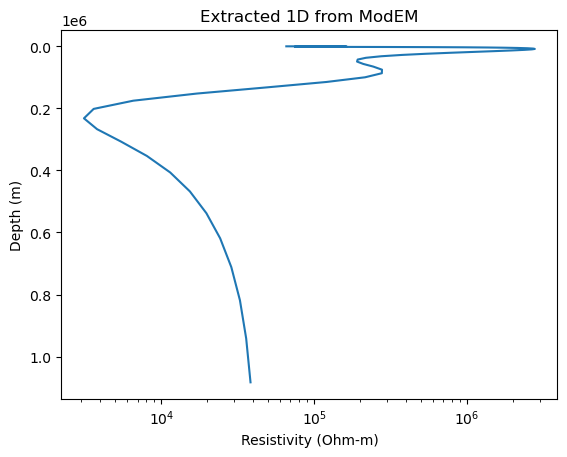

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.semilogx(rho_1d, depth)

plt.gca().invert_yaxis()
plt.xlabel("Resistivity (Ohm-m)")
plt.ylabel("Depth (m)")
plt.title("Extracted 1D from ModEM")

plt.show()

In [13]:
rho_modem_log = np.log10(rho_1d)
depth_km = depth / 1000


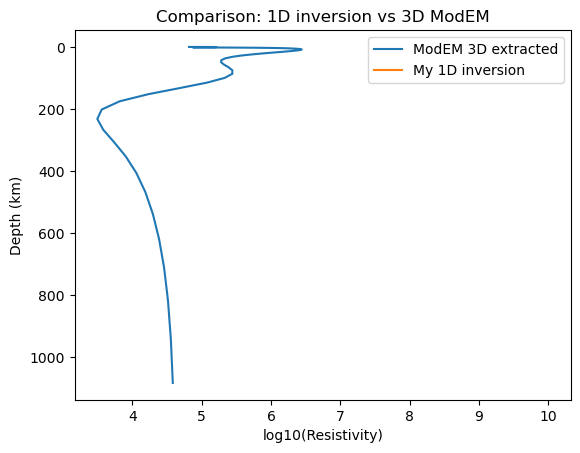

In [17]:
plt.figure()

# ModEM (converted)
plt.plot(rho_modem_log, depth_km, label="ModEM 3D extracted")

# Your inversion (middle panel curve)
plt.plot(10, 350, label="My 1D inversion")

plt.gca().invert_yaxis()
plt.xlabel("log10(Resistivity)")
plt.ylabel("Depth (km)")
plt.legend()

plt.title("Comparison: 1D inversion vs 3D ModEM")

plt.show()

In [15]:
%pip install h5py

Note: you may need to restart the kernel to use updated packages.


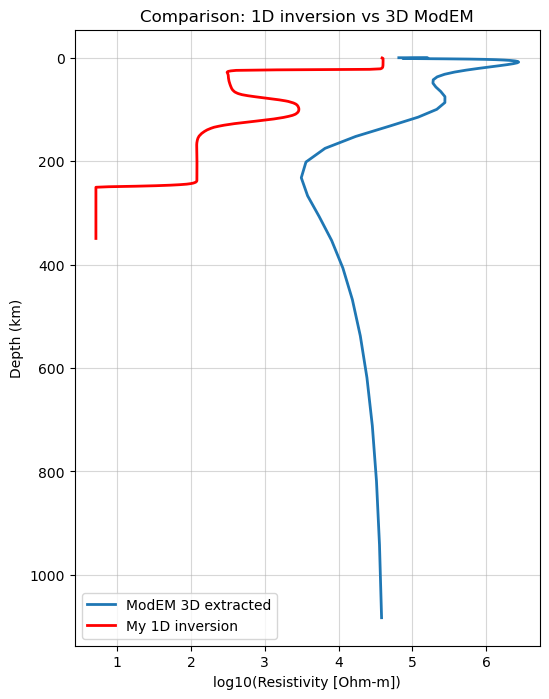

In [18]:

import h5py
import numpy as np

# 1. Load the processed statistical information from your inversion
# Note: Adjust the path if your .mat file is in a different folder (e.g., 'Test/')
mat_path = "MT_TD_Chain_Stat_info.mat"

with h5py.File(mat_path, 'r') as f:
    # In HDF5 format, the structure S is a group
    S = f['S']
    
    # Extract pmean (mean log10 resistivity) and zPlot (depth in meters)
    # Note: h5py reads arrays in transposed order (C-style vs Fortran-style)
    rho_my_log = np.array(S['pmean']).flatten()
    depth_my_m = np.array(S['zPlot']).flatten()

# 2. Convert depth from meters to kilometers
depth_my_km = depth_my_m / 1000.0

# 3. Now you can run your plotting code
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))

# ModEM (converted)
plt.plot(rho_modem_log, depth_km, label="ModEM 3D extracted", linewidth=2)

# Your inversion (the mean posterior curve)
plt.plot(rho_my_log, depth_my_km, label="My 1D inversion", color='red', linewidth=2)

plt.gca().invert_yaxis()
plt.xlabel("log10(Resistivity [Ohm-m])")
plt.ylabel("Depth (km)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title("Comparison: 1D inversion vs 3D ModEM")

plt.show()